### Exploratory Data Analysis for Research Question 2 

How has digital financial services adoption changed between 2021 and 2025 has this change 
across demographic groups?

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

rq_1 = pd.read_csv("data_cleaned.csv")

In [2]:
rq_1.head()

,wage_payment_method,no_account_family_member,debit_card_ownership,ever_had_mobile_money_account,survey_year,ever_had_bank_account,...,received_transfers,no_account_insufficient_funds,codes_found,gender,age_group,education_original
0,2.0,NaN,2.0,2.0,2021,NaN,...,1.0,NaN,False,Female,23_29,3.0
1,2.0,NaN,1.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0
2,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
3,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
4,NaN,NaN,2.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0


In [4]:
year_adoption = (rq_1.groupby("survey_year")["any_digital_payment"].mean()).reset_index()
year_adoption.head()

,survey_year,any_digital_payment
0,2021,0.963618
1,2024,0.812000


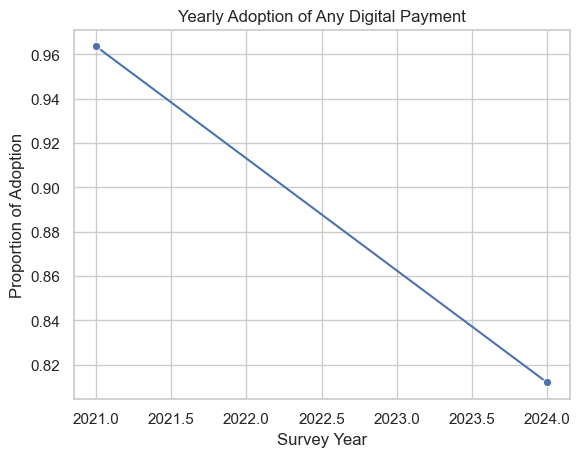

In [5]:
sns.lineplot(data=year_adoption, x="survey_year", y="any_digital_payment", marker="o")
plt.title("Yearly Adoption of Any Digital Payment")
plt.xlabel("Survey Year")
plt.ylabel("Proportion of Adoption")
plt.show()

### Percentage-point change in adoption of any digital payment

In [7]:
rates = (rq_1.groupby("survey_year")["any_digital_payment"].mean())
change = (rates.loc[2024]-rates.loc[2021]) 
print(f"Percentage-point change in adoption of any digital payment from 2021 to 2024: {change:.2f}") 

Percentage-point change in adoption of any digital payment from 2021 to 2024: -0.15


Percentage-point change in adoption of any digital payment from 2021 to 2024: -0.15 means a slight decline in adoption over the period.

### RQ2: Year x Gender

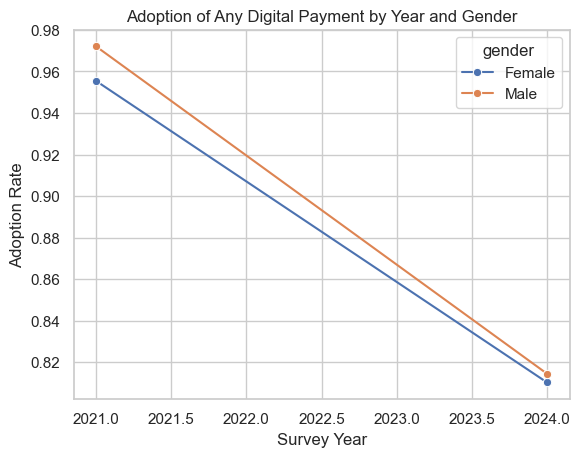

In [8]:
gender_year_adoption = rq_1.groupby(["survey_year", "gender"])["any_digital_payment"].mean().reset_index()
sns.lineplot(data=gender_year_adoption, x="survey_year", y="any_digital_payment", hue="gender", marker="o")
plt.title("Adoption of Any Digital Payment by Year and Gender")
plt.xlabel("Survey Year")
plt.ylabel("Adoption Rate")
plt.show()

### Statistical hypothesis testing

- The tests below use an alpha level of 0.05. Because `any_digital_payment` is binary, its mean is an adoption proportion
- The t-test and ANOVA therefore compare adoption rates
- while the chi-square tests assess categorical association
- The F test compares the variances of the binary outcome and should be treated as a supplementary diagnostic, not as the main test of adoption change

In [11]:
from scipy import stats

alpha = 0.05
analysis = rq_1[["survey_year", "gender", "any_digital_payment"]].dropna().copy()
analysis["survey_year"] = analysis["survey_year"].astype(int)
analysis["any_digital_payment"] = analysis["any_digital_payment"].astype(int)

years = sorted(analysis["survey_year"].unique())
first_year, last_year = years[0], years[-1]
first = analysis.loc[analysis["survey_year"] == first_year, "any_digital_payment"]
last = analysis.loc[analysis["survey_year"] == last_year, "any_digital_payment"]

print("Adoption rates by year and gender")
print(analysis.groupby(["survey_year", "gender"])["any_digital_payment"].agg(["count", "mean"]).round(4))
print(f"\nOverall adoption change ({first_year} to {last_year}): "
      f"{first.mean():.3f} to {last.mean():.3f} "
      f"({last.mean() - first.mean():+.3f}, {(last.mean() - first.mean()) * 100:+.1f} percentage points)")

Adoption rates by year and gender
                    count    mean
survey_year gender               
2021        Female    516  0.9554
            Male      501  0.9721
2024        Female    585  0.8103
            Male      415  0.8145

Overall adoption change (2021 to 2024): 0.964 to 0.812 (-0.152, -15.2 percentage points)


In [ ]:
# Welch t-test: H0 = equal mean adoption rates in the first and last observed years.
t_stat, t_p = stats.ttest_ind(first, last, equal_var=False)

print("Welch independent-samples t-test")
print(f"H0: mean adoption is equal in {first_year} and {last_year}")
print(f"t = {t_stat:.3f}, p = {t_p:.4g}")
print("Decision:", "Reject H0" if t_p < alpha else "Fail to reject H0") # type: ignore
print("Interpretation: adoption rates differ significantly between the two years."
      if t_p < alpha else # type: ignore
      "Interpretation: the observed adoption difference is not statistically significant.")

Welch independent-samples t-test
H0: mean adoption is equal in 2021 and 2024
t = 11.078, p = 2.018e-27
Decision: Reject H0
Interpretation: adoption rates differ significantly between the two years.


In [ ]:
# Two-sided F test: H0 = equal adoption variances in the first and last observed years. 
# Ha = adoption variances in the first and last observed years are not equal.
first_var = first.var(ddof=1)
last_var = last.var(ddof=1)
f_stat = first_var / last_var if last_var else np.inf
f_df1, f_df2 = len(first) - 1, len(last) - 1
f_cdf = stats.f.cdf(f_stat, f_df1, f_df2)
f_p = min(2 * min(f_cdf, 1 - f_cdf), 1.0)

print("Two-sided F test for equality of variances")
print(f"H0: adoption variances are equal in {first_year} and {last_year}")
print(f"F({f_df1}, {f_df2}) = {f_stat:.3f}, p = {f_p:.4g}")
print("Decision:", "Reject H0" if f_p < alpha else "Fail to reject H0")
print("Interpretation: the variances differ, although this result is supplementary because the outcome is binary."
      if f_p < alpha else
      "Interpretation: there is no evidence of different variances.")

Two-sided F test for equality of variances
H0: adoption variances are equal in 2021 and 2024
F(1016, 999) = 0.230, p = 1.49e-111
Decision: Reject H0
Interpretation: the variances differ, although this result is supplementary because the outcome is binary.


In [ ]:
# Chi-square test 1: H0 = survey year and adoption status are independent.  Ha = survey year and adoption status are not independent.
year_table = pd.crosstab(analysis["survey_year"], analysis["any_digital_payment"])
chi2_year, chi2_year_p, chi2_year_df, _ = stats.chi2_contingency(year_table)

print("Chi-square test: survey year x adoption status")
print(year_table)
print(f"chi2({chi2_year_df}) = {chi2_year:.3f}, p = {chi2_year_p:.4g}")
print("Decision:", "Reject H0" if chi2_year_p < alpha else "Fail to reject H0") # type: ignore
print("Interpretation: survey year is significantly associated with adoption status."
      if chi2_year_p < alpha else # type: ignore
      "Interpretation: there is no significant association between year and adoption status.")

Chi-square test: survey year x adoption status
any_digital_payment    0    1
survey_year                  
2021                  37  980
2024                 188  812
chi2(1) = 115.428, p = 6.342e-27
Decision: Reject H0
Interpretation: survey year is significantly associated with adoption status.


In [ ]:
# Chi-square test 2: H0 = gender and adoption status are independent. Ha = gender and adoption status are not independent.
gender_table = pd.crosstab(analysis["gender"], analysis["any_digital_payment"])
chi2_gender, chi2_gender_p, chi2_gender_df, _ = stats.chi2_contingency(gender_table)

print("Chi-square test: gender x adoption status")
print(gender_table)
print(f"chi2({chi2_gender_df}) = {chi2_gender:.3f}, p = {chi2_gender_p:.4g}")
print("Decision:", "Reject H0" if chi2_gender_p < alpha else "Fail to reject H0") # type: ignore
print("Interpretation: gender is significantly associated with adoption status."
      if chi2_gender_p < alpha else # type: ignore
      "Interpretation: there is no significant association between gender and adoption status.")

Chi-square test: gender x adoption status
any_digital_payment    0    1
gender                       
Female               134  967
Male                  91  825
chi2(1) = 2.302, p = 0.1292
Decision: Fail to reject H0
Interpretation: there is no significant association between gender and adoption status.


In [ ]:
# One-way ANOVA: H0 = mean adoption is equal across all observed years. 
# Ha = at least one year's mean adoption is different. 
groups_by_year = [group["any_digital_payment"].to_numpy()
                  for _, group in analysis.groupby("survey_year")]
anova_year = stats.f_oneway(*groups_by_year)

print("One-way ANOVA: adoption by survey year")
print("H0: mean adoption is equal across all observed years")
print(f"F = {anova_year.statistic:.3f}, p = {anova_year.pvalue:.4g}")
print("Decision:", "Reject H0" if anova_year.pvalue < alpha else "Fail to reject H0")
print("Interpretation: at least one year's adoption rate differs significantly."
      if anova_year.pvalue < alpha else
      "Interpretation: yearly adoption rates are not significantly different.")

One-way ANOVA: adoption by survey year
H0: mean adoption is equal across all observed years
F = 124.028, p = 5.353e-28
Decision: Reject H0
Interpretation: at least one year's adoption rate differs significantly.


In [ ]:
# Two-way ANOVA: year, gender, and their interaction.
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("any_digital_payment ~ C(survey_year) * C(gender)", data=analysis).fit()
two_way = sm.stats.anova_lm(model, typ=2)

print("Two-way ANOVA: year, gender, and year x gender interaction")
print(two_way[["sum_sq", "df", "F", "PR(>F)"]].round(4))
for term, label in [("C(survey_year)", "Year"),
                    ("C(gender)", "Gender"),
                    ("C(survey_year):C(gender)", "Year x gender interaction")]:
    p_value = two_way.loc[term, "PR(>F)"]
    print(f"{label}: {'significant' if p_value < alpha else 'not statistically significant'} " # type: ignore
          f"(p = {p_value:.4g})")

print("Interpretation: a non-significant interaction means the adoption trend is statistically similar across genders."
      if two_way.loc["C(survey_year):C(gender)", "PR(>F)"] >= alpha else # type: ignore
      "Interpretation: the adoption trend differs significantly by gender.")

Two-way ANOVA: year, gender, and year x gender interaction
                            sum_sq      df         F  PR(>F)
C(survey_year)             11.3963     1.0  121.8729  0.0000
C(gender)                   0.0554     1.0    0.5925  0.4416
C(survey_year):C(gender)    0.0192     1.0    0.2051  0.6507
Residual                  188.2353  2013.0       NaN     NaN
Year: significant (p = 1.493e-27)
Gender: not statistically significant (p = 0.4416)
Year x gender interaction: not statistically significant (p = 0.6507)
Interpretation: a non-significant interaction means the adoption trend is statistically similar across genders.


### Overall interpretation

- Adoption declined from 96.4% in 2021 to 81.2% in 2024, a 15.2 percentage-point decrease
- The year effect is statistically significant in the t-test, chi-square test, and ANOVA
- Gender is not statistically significant, and the year x gender interaction is not significant
- The nearly parallel gender lines therefore suggest a similar decline for both genders
- These results show association, not causation. The current dataset contains 2021 and 2024, so it does not establish a 2025 trend

### Income x Year interaction 
- Did lower-income and higher-income groups experience different rates of digital-payment adoption growth?

In [19]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

logit_data = rq_1[["any_digital_payment", "income_quintile", "survey_year"]].dropna().copy()
logit_data["any_digital_payment"] = logit_data["any_digital_payment"].astype(int)

# Treat income quintile and survey year as categorical predictors.
logit_data["income_quintile"] = logit_data["income_quintile"].astype(str)
logit_data["survey_year"] = logit_data["survey_year"].astype(str)

additive_model = smf.logit(
    "any_digital_payment ~ C(income_quintile) + C(survey_year)",
    data=logit_data
).fit(disp=False, maxiter=200)

interaction_model = smf.logit(
    "any_digital_payment ~ C(income_quintile) * C(survey_year)",
    data=logit_data
).fit(disp=False, maxiter=200)

print("Logistic regression: income quintile x survey year")
print("Outcome: any_digital_payment")
print("Reference categories:")
print(f"  income_quintile = {sorted(logit_data['income_quintile'].unique())[0]}")
print(f"  survey_year = {sorted(logit_data['survey_year'].unique())[0]}")
print(f"\nN = {len(logit_data)}")
print(f"McFadden pseudo-R2 = {interaction_model.prsquared:.4f}")

results = pd.DataFrame({
    "coefficient": interaction_model.params,
    "odds_ratio": np.exp(interaction_model.params),
    "p_value": interaction_model.pvalues
})
print("\nFull interaction model coefficients and odds ratios")
print(results.round(4))

# Likelihood-ratio test: H0 = all income-quintile x year interaction terms are zero.
lr_stat = 2 * (interaction_model.llf - additive_model.llf)
lr_df = int(interaction_model.df_model - additive_model.df_model)
lr_p = chi2.sf(lr_stat, lr_df)

print("\nLikelihood-ratio test for the interaction")
print("H0: the effect of survey year is the same across income quintiles")
print(f"LR chi2({lr_df}) = {lr_stat:.3f}, p = {lr_p:.4g}")
print("Decision:", "Reject H0" if lr_p < alpha else "Fail to reject H0")
print("Interpretation: the year trend differs significantly across income quintiles."
      if lr_p < alpha else
      "Interpretation: there is no statistically significant evidence that the year trend differs across income quintiles.")

Logistic regression: income quintile x survey year
Outcome: any_digital_payment
Reference categories:
  income_quintile = Q1 Lowest
  survey_year = 2021

N = 2017
McFadden pseudo-R2 = 0.1192

Full interaction model coefficients and odds ratios
                                                    coefficient  odds_ratio  \
Intercept                                                2.6210     13.7500   
C(income_quintile)[T.Q2]                                 0.1278      1.1364   
C(income_quintile)[T.Q3]                                 0.4700      1.6000   
C(income_quintile)[T.Q4]                                 1.9116      6.7636   
C(income_quintile)[T.Q5 Highest]                         0.7463      2.1091   
C(survey_year)[T.2024]                                  -1.7481      0.1741   
C(income_quintile)[T.Q2]:C(survey_year)[T.2024]          0.7104      2.0349   
C(income_quintile)[T.Q3]:C(survey_year)[T.2024]         -0.1566      0.8550   
C(income_quintile)[T.Q4]:C(survey_year)[T.202

### Logistic regression interpretation

- The model estimates the probability of `any_digital_payment = 1` using income quintile, survey year, and their interaction.
- The reference group is **Q1 Lowest income in 2021**. The 2024 coefficient for this group is negative and statistically significant, showing a substantial decline in adoption odds from 2021 to 2024.
- The likelihood-ratio interaction test gives **LR chi-square(4) = 6.288, p = 0.179**. At the 5% significance level, fail to reject $H_0$: the effect of survey year is the same across income quintiles.
- Therefore, although some income groups have different baseline adoption levels, there is no statistically significant evidence that income quintiles experienced different changes over time.
- The Q4 coefficient is significantly higher than Q1 in 2021, with an odds ratio of approximately **6.76**, indicating higher baseline adoption odds for Q4 relative to Q1. This is a baseline income difference, not evidence of a different time trend.
- Odds ratios for interaction terms compare each income group’s 2024 change with the Q1 group’s 2024 change. Since their individual p-values are all above 0.05, none provides strong evidence of a different income-specific trend.

**To sum up:** Survey year is associated with lower digital-payment adoption, and income quintile may explain baseline differences, but the income-quintile-by-year interaction is not statistically significant in this sample.